# Problem statement
"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base. One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering * Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information. The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being. However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient

# Data Collection
The Dataset is collected from https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction The data consists of 20 column and 4888 rows.

In [76]:
# import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
#import plotly.express as px

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import BaggingClassifier

from sklearn.metrics import (accuracy_score, classification_report, precision_score, recall_score, f1_score)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("✅ Libraries imported successfully!")

import warnings
warnings.filterwarnings("ignore")

✅ Libraries imported successfully!


In [77]:
# read the data
df = pd.read_csv('Travel.csv')
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


#Data Exploration

In [78]:
print("Column Names: ", df.columns)

Column Names:  Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='object')


In [79]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print(f"Numerical Columns: {numeric_cols}")
print(f"Categorical Columns: {categorical_cols}")

Numerical Columns: ['CustomerID', 'ProdTaken', 'Age', 'CityTier', 'DurationOfPitch', 'NumberOfPersonVisiting', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'NumberOfChildrenVisiting', 'MonthlyIncome']
Categorical Columns: ['TypeofContact', 'Occupation', 'Gender', 'ProductPitched', 'MaritalStatus', 'Designation']


In [80]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 4888
Number of Columns: 20


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [82]:
df.describe()

,CustomerID,ProdTaken,Age,CityTier,DurationOfPitch,NumberOfPersonVisiting,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,MonthlyIncome
count,4888.000000,4888.000000,4662.000000,4888.000000,4637.000000,4888.000000,4843.000000,4862.000000,4748.000000,4888.000000,4888.000000,4888.000000,4822.000000,4655.000000
mean,202443.500000,0.188216,37.622265,1.654255,15.490835,2.905074,3.708445,3.581037,3.236521,0.290917,3.078151,0.620295,1.187267,23619.853491
std,1411.188388,0.390925,9.316387,0.916583,8.519643,0.724891,1.002509,0.798009,1.849019,0.454232,1.365792,0.485363,0.857861,5380.698361
min,200000.000000,0.000000,18.000000,1.000000,5.000000,1.000000,1.000000,3.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1000.000000
25%,201221.750000,0.000000,31.000000,1.000000,9.000000,2.000000,3.000000,3.000000,2.000000,0.000000,2.000000,0.000000,1.000000,20346.000000
50%,202443.500000,0.000000,36.000000,1.000000,13.000000,3.000000,4.000000,3.000000,3.000000,0.000000,3.000000,1.000000,1.000000,22347.000000
75%,203665.250000,0.000000,44.000000,3.000000,20.000000,3.000000,4.000000,4.000000,4.000000,1.000000,4.000000,1.000000,2.000000,25571.000000
max,204887.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,5.000000,1.000000,3.000000,98678.000000


In [83]:
df.describe(include='O')

,TypeofContact,Occupation,Gender,ProductPitched,MaritalStatus,Designation
count,4863,4888,4888,4888,4888,4888
unique,2,4,3,5,4,5
top,Self Enquiry,Salaried,Male,Basic,Married,Executive
freq,3444,2368,2916,1842,2340,1842


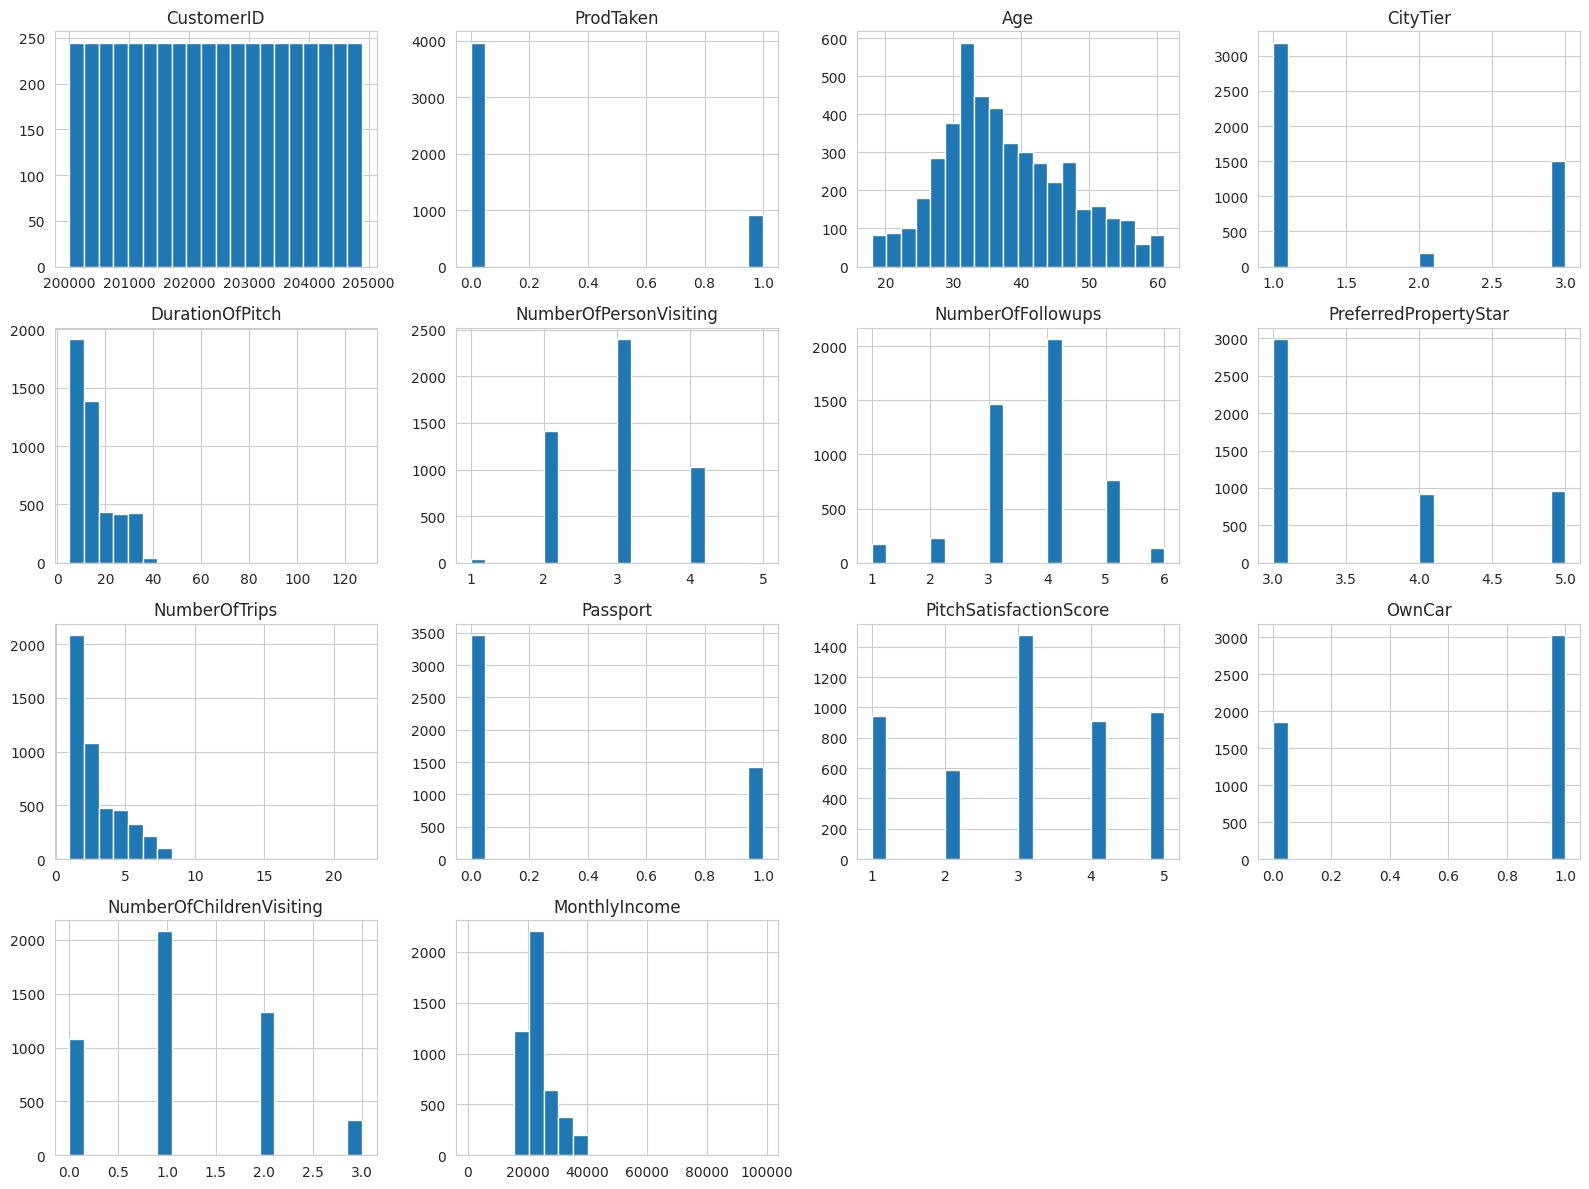

In [84]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(16,12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4,4,i)
    plt.hist(df[col], bins=20)
    plt.title(col)

plt.tight_layout()
plt.show()

<Axes: >

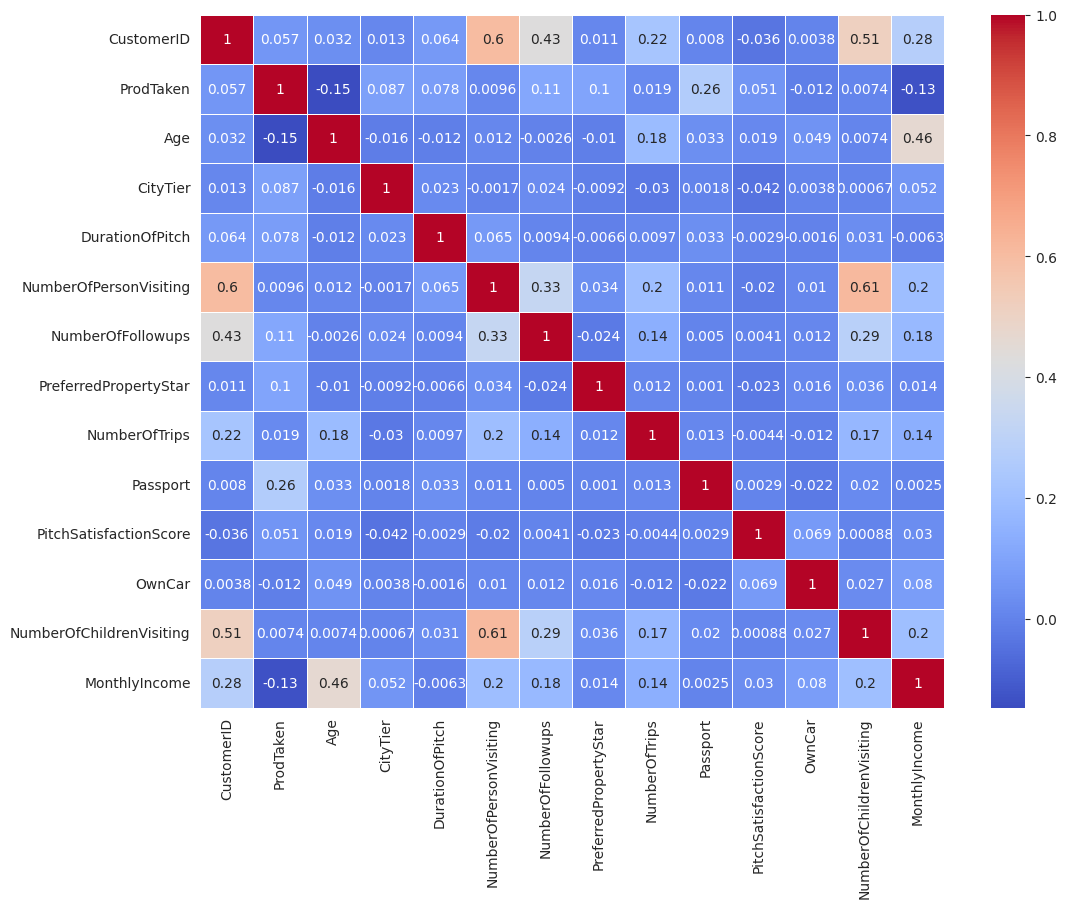

In [85]:
plt.figure(figsize=(12,9))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', linewidth=0.5)

In [86]:
for col in categorical_cols:
    print(df[col].value_counts())
    print('===========')

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64
Occupation
Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2
Name: count, dtype: int64
Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64
ProductPitched
Basic           1842
Deluxe          1732
Standard         742
Super Deluxe     342
King             230
Name: count, dtype: int64
MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64
Designation
Executive         1842
Manager           1732
Senior Manager     742
AVP                342
VP                 230
Name: count, dtype: int64


In [87]:
d = df["ProdTaken"].value_counts()
target = pd.DataFrame(d)
target

,count
ProdTaken,
0,3968
1,920


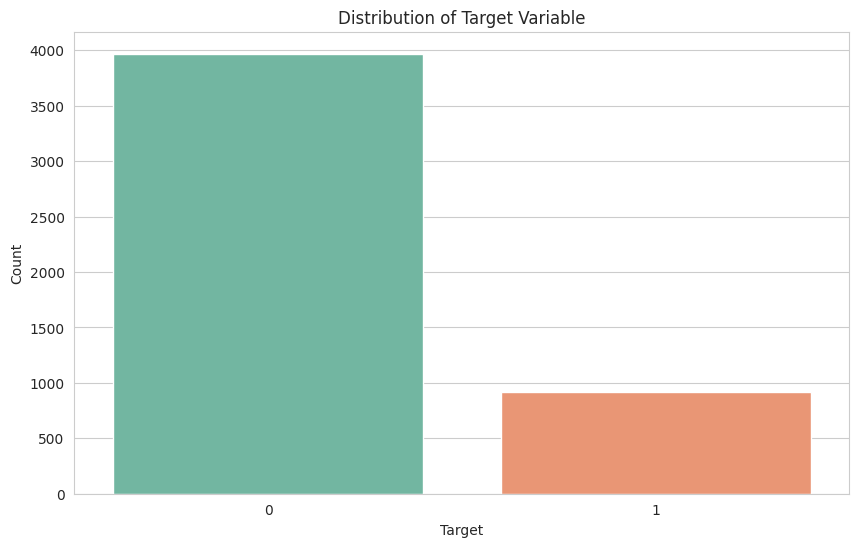

In [88]:
sns.countplot(x='ProdTaken', data=df, palette='Set2')
plt.title('Distribution of Target Variable')
plt.xlabel('Target')
plt.ylabel('Count')
#plt.xticks(rotation=45)
plt.show()

In [89]:
missing_cnts = df.isna().sum()
missing = missing_cnts[missing_cnts > 0]
missing

,0
Age,226
TypeofContact,25
DurationOfPitch,251
NumberOfFollowups,45
PreferredPropertyStar,26
NumberOfTrips,140
NumberOfChildrenVisiting,66
MonthlyIncome,233


In [90]:
df.isna().sum().sum()

np.int64(1012)

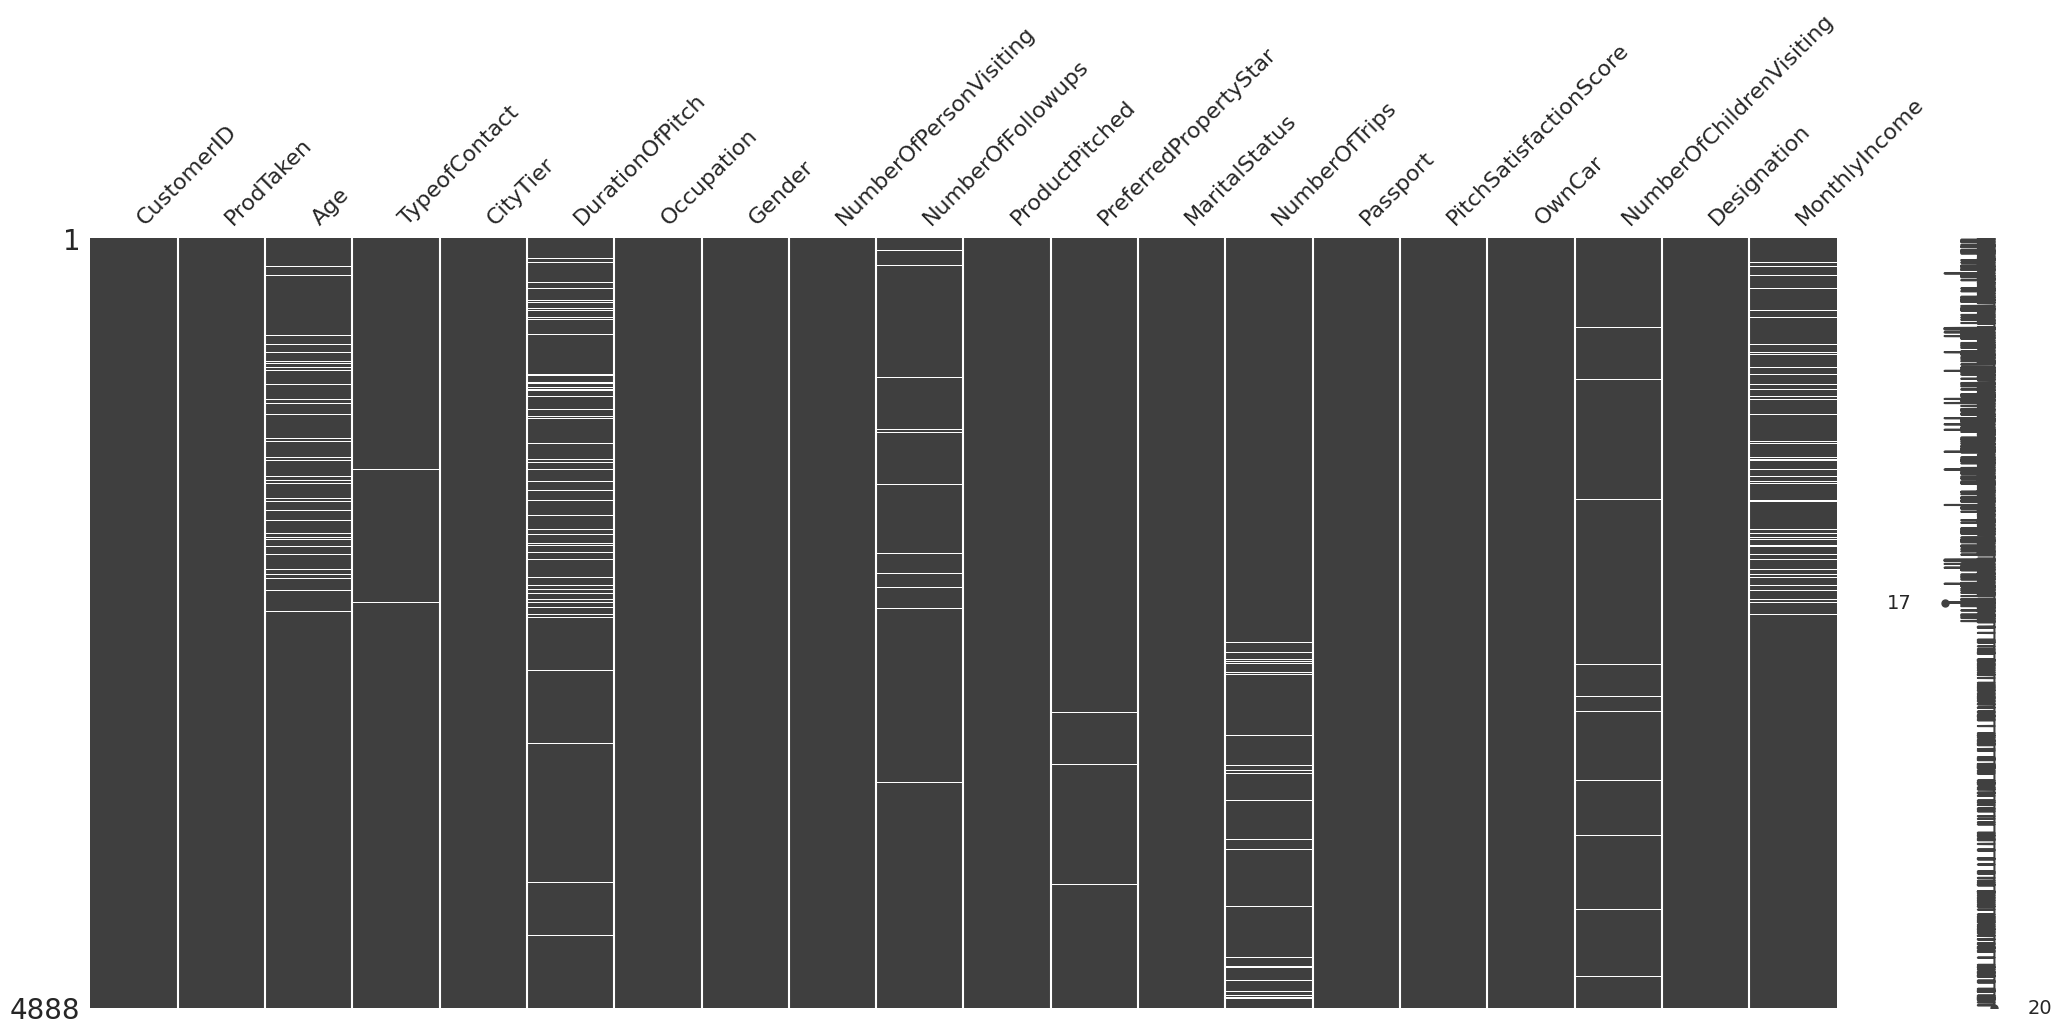

In [91]:
import missingno as msno
msno.matrix(df)
plt.show()

## Data Cleaning

In [92]:
df.drop("CustomerID", axis=1, inplace=True)

In [93]:
# Handling features values
df['Gender'] = df['Gender'].replace('Fe Male', 'Female')
df['MaritalStatus'] = df['MaritalStatus'].replace('Single', 'Unmarried')

In [94]:
df[['Gender', 'MaritalStatus']].value_counts()

Gender  MaritalStatus
Male    Married          1444
        Unmarried         908
Female  Married           896
        Unmarried         690
Male    Divorced          564
Female  Divorced          386
Name: count, dtype: int64

In [95]:
fmissings = [feature for feature in df.columns if df[feature].isna().sum() > 0]

In [96]:
fmissings

['Age',
 'TypeofContact',
 'DurationOfPitch',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'NumberOfChildrenVisiting',
 'MonthlyIncome']

In [99]:
numnan_cols = df[fmissings].select_dtypes(include=np.number).columns.to_list()
catnan_cols = df[fmissings].select_dtypes(exclude=np.number).columns.to_list()
print(numnan_cols)
print(catnan_cols)

['Age', 'DurationOfPitch', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'NumberOfChildrenVisiting', 'MonthlyIncome']
['TypeofContact']


In [100]:
# filling missing with mean and mode
for feature in numnan_cols:
    df[feature] = df[feature].fillna(df[feature].mean())

for feature in catnan_cols:
    df[feature] = df[feature].fillna(df[feature].mode()[0])

In [102]:
df.isna().sum().sum()

np.int64(0)

## Feature Engineering & Encoding

In [103]:
# Summing all the visits
df['Total_visits'] = df['NumberOfChildrenVisiting'] + df['NumberOfPersonVisiting']
df.drop(['NumberOfChildrenVisiting','NumberOfPersonVisiting'],inplace=True,axis=1)

In [104]:
# Splitting into train and test sets
X = df.drop(['ProdTaken'], axis=1)
y = df['ProdTaken']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [105]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

scaler = StandardScaler()
encoder = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer([
("StandardScaler", scaler, num_cols),
("OneHotEncoder", encoder, cat_cols)])

In [106]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

#### Build a classification model using support vector machine. Use standalone model as well as Bagging model and check if you see any difference in the performance.

In [112]:
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

SVC(random_state=42)

In [113]:
y_pred = svm_model.predict(X_test)

In [114]:
print("=== Standalone SVM ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

=== Standalone SVM ===
Accuracy: 0.8650306748466258
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       787
           1       0.84      0.38      0.53       191

    accuracy                           0.87       978
   macro avg       0.85      0.68      0.72       978
weighted avg       0.86      0.87      0.84       978



In [116]:
bag_classifier = BaggingClassifier(estimator=SVC(kernel='rbf'), n_estimators=20, random_state=42)
bag_classifier.fit(X_train, y_train)

BaggingClassifier(estimator=SVC(), n_estimators=20, random_state=42)

In [117]:
y_pred_bag = bag_classifier.predict(X_test)

In [118]:
print("=== Bagging + SVM ===")
print("Accuracy:", accuracy_score(y_test, y_pred_bag))
print(classification_report(y_test, y_pred_bag))

=== Bagging + SVM ===
Accuracy: 0.8670756646216768
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       787
           1       0.86      0.38      0.53       191

    accuracy                           0.87       978
   macro avg       0.86      0.68      0.73       978
weighted avg       0.87      0.87      0.85       978



#### Now use decision tree classifier. Use standalone model as well as Bagging and check if you notice any difference in performance

In [119]:
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [120]:
y_pred = dt_classifier.predict(X_test)

In [121]:
print("=== Standalone Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

=== Standalone Decision Tree ===
Accuracy: 0.9212678936605317
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       787
           1       0.80      0.80      0.80       191

    accuracy                           0.92       978
   macro avg       0.88      0.87      0.87       978
weighted avg       0.92      0.92      0.92       978



In [122]:
bag_dt_classifier = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
bag_dt_classifier.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50,
                  random_state=42)

In [123]:
y_pred_bag = bag_dt_classifier.predict(X_test)

In [124]:
print("=== Bagging + Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_bag))
print(classification_report(y_test, y_pred_bag))

=== Bagging + Decision Tree ===
Accuracy: 0.9458077709611452
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       787
           1       0.95      0.76      0.85       191

    accuracy                           0.95       978
   macro avg       0.95      0.88      0.91       978
weighted avg       0.95      0.95      0.94       978



#### then use random forest classifier. Use standalone model as well as Bagging and check if you notice any difference in performance

In [126]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [127]:
y_pred = rf_classifier.predict(X_test)

In [128]:
print("=== Standalone Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

=== Standalone Random Forest ===
Accuracy: 0.9314928425357873
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       787
           1       0.97      0.67      0.79       191

    accuracy                           0.93       978
   macro avg       0.95      0.83      0.88       978
weighted avg       0.93      0.93      0.93       978



In [132]:
bag_rf_classifier = BaggingClassifier(estimator=RandomForestClassifier(n_estimators=100),
                                      n_estimators=100,
                                      random_state=42)
bag_rf_classifier.fit(X_train, y_train)

BaggingClassifier(estimator=RandomForestClassifier(), n_estimators=100,
                  random_state=42)

In [133]:
y_pred_bag = bag_rf_classifier.predict(X_test)

In [134]:
print("=== Bagging + Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_bag))
print(classification_report(y_test, y_pred_bag))

=== Bagging + Random Forest ===
Accuracy: 0.9038854805725971
              precision    recall  f1-score   support

           0       0.90      1.00      0.94       787
           1       0.97      0.52      0.68       191

    accuracy                           0.90       978
   macro avg       0.93      0.76      0.81       978
weighted avg       0.91      0.90      0.89       978



#### Comparing performance of them to figure out where it makes most sense to use bagging and why. What conditions bagging works the best.

In [135]:
results = []

models = {
    "Standalone SVM": svm_model,
    "Bagging + SVM": bag_classifier,
    "Standalone Decision Tree": dt_classifier,
    "Bagging + Decision Tree": bag_dt_classifier,
    "Standalone Random Forest": rf_classifier,
    "Bagging + Random Forest": bag_rf_classifier
}

for name, model in models.items():
    y_pred_model = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred_model),
        "Precision": precision_score(y_test, y_pred_model),
        "Recall": recall_score(y_test, y_pred_model),
        "F1-score": f1_score(y_test, y_pred_model)
    })

performance_df = pd.DataFrame(results)
performance_df = performance_df.sort_values(by="F1-score", ascending=False)
performance_df.reset_index(drop=True, inplace=True)

print("=== Performance Comparison ===")
print(performance_df)

=== Performance Comparison ===
                      Model  Accuracy  Precision    Recall  F1-score
0   Bagging + Decision Tree  0.945808   0.948052  0.764398  0.846377
1  Standalone Decision Tree  0.921268   0.800000  0.795812  0.797900
2  Standalone Random Forest  0.931493   0.969697  0.670157  0.792570
3   Bagging + Random Forest  0.903885   0.970874  0.523560  0.680272
4             Bagging + SVM  0.867076   0.858824  0.382199  0.528986
5            Standalone SVM  0.865031   0.839080  0.382199  0.525180


#Notes&Observations
- **Decision Tree**
  - Bagging improves Precision and F1-score → reduces overfitting.

- **Random Forest**
  - Already an ensemble, additional Bagging reduces performance on Class 1 so no need to Bag.
- **SVM**
  - Bagging adds very little improvement → not useful.  
